In [3]:
import pandas as pd
import numpy as np

In [58]:
models = pd.read_parquet('../data_raw/models.parquet')

# Model Cohorts

In [60]:
def cohort_sort_key(cohort):
    if cohort == 'Unknown':
        return (9999, 9)
    q, year = cohort.split('-')
    return (int(year), int(q[1]))


counts = counts.sort_values('cohort', key=lambda s: s.map(cohort_sort_key))

print(counts.to_string(index=False))
print(f"\nTotal: {counts['count'].sum():,}")

 cohort  count
Q1-2022     17
Q2-2022      8
Q3-2022      1
Q4-2022      8
Q1-2023     14
Q2-2023     26
Q3-2023     36
Q4-2023     75
Q1-2024    145
Q2-2024    465
Q3-2024    663
Q4-2024   1116
Q1-2025   1472
Unknown    530

Total: 4,576


In [59]:
N_PER_COHORT = 30
SEED = 42
STRAT_BY = "arch"  # 'none' | 'arch' | 'size'

df = models
df['release_date'] = pd.to_datetime(df['Upload To Hub Date'], errors='coerce')




In [62]:
df.to_parquet("../data_clean/models.parquet", index=False)

In [61]:
dist = (
    df[df['cohort'] != 'Unknown']
    .groupby(['cohort', 'Architecture'])
    .size()
    .reset_index(name='count')
    .sort_values('cohort', key=lambda s: s.map(cohort_sort_key))
)

# pivot: rows = cohort, columns = architecture family
pivot = dist.pivot_table(index='cohort', columns='Architecture', values='count', fill_value=0)

# sort rows chronologically
pivot = pivot.loc[sorted(pivot.index, key=cohort_sort_key)]

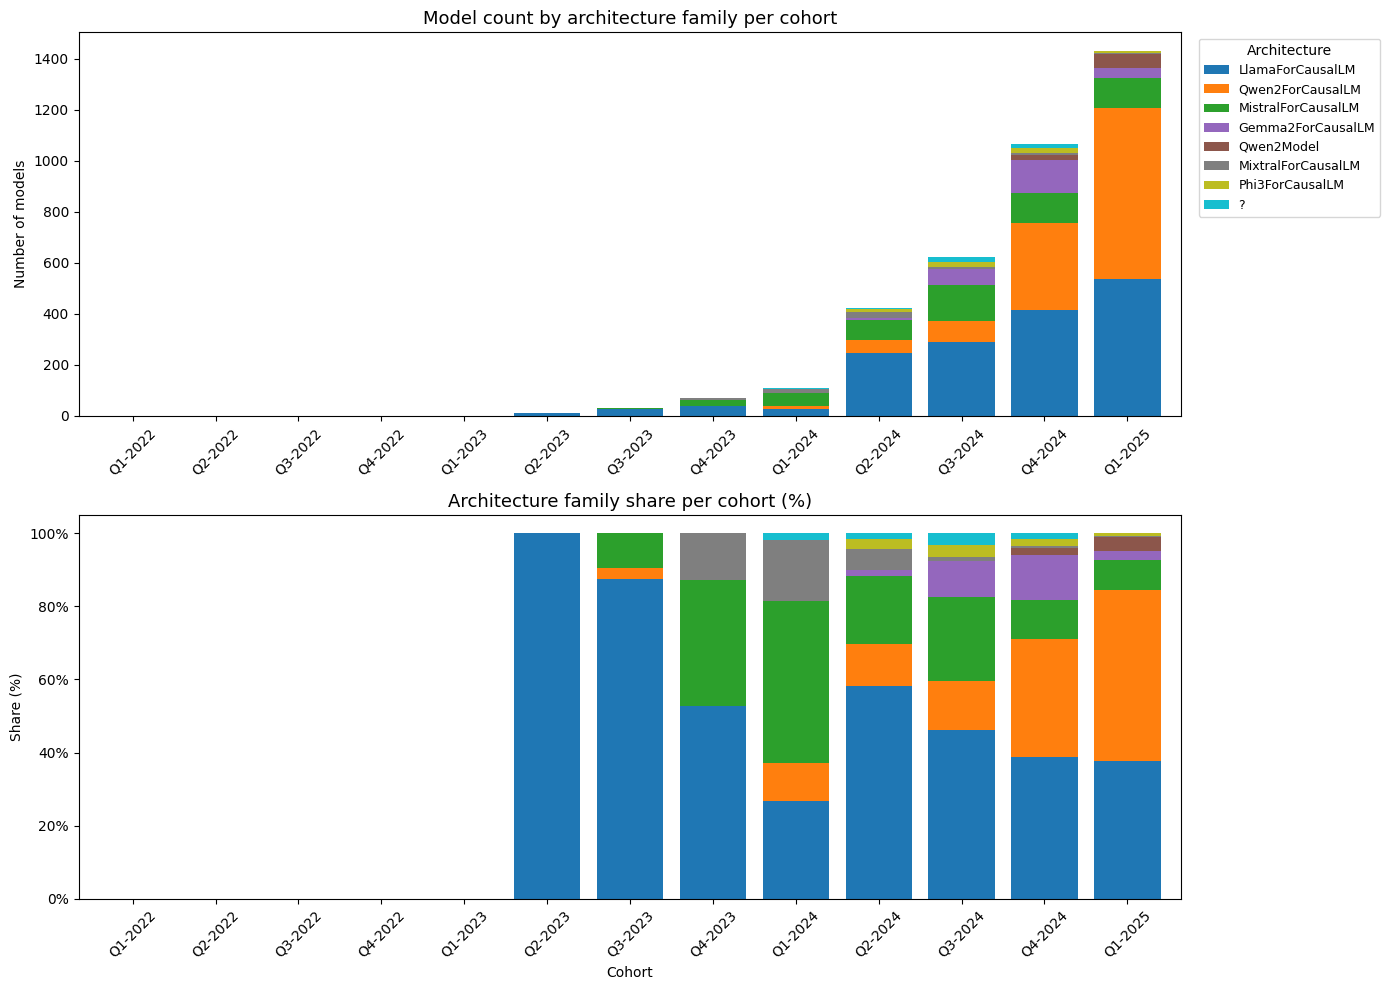

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# keep top 8 families for readability
top_families = pivot.sum().sort_values(ascending=False).head(8).index
pivot_plot = pivot[top_families]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── absolute counts ───────────────────────────────────────────────────────────
pivot_plot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', width=0.8)
axes[0].set_title('Model count by architecture family per cohort', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of models')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Architecture', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── percentage share ──────────────────────────────────────────────────────────
pivot_pct = pivot_plot.div(pivot_plot.sum(axis=1), axis=0).mul(100)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', width=0.8, legend=False)
axes[1].set_title('Architecture family share per cohort (%)', fontsize=13)
axes[1].set_xlabel('Cohort')
axes[1].set_ylabel('Share (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('architecture_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

# BBH Results

In [16]:
import json, glob
import pandas as pd
from pathlib import Path
import re

BBH_TASKS = [
    "leaderboard_bbh_boolean_expressions",
    "leaderboard_bbh_causal_judgement",
    "leaderboard_bbh_date_understanding",
    "leaderboard_bbh_disambiguation_qa",
    "leaderboard_bbh_formal_fallacies",
    "leaderboard_bbh_geometric_shapes",
    "leaderboard_bbh_hyperbaton",
    "leaderboard_bbh_logical_deduction_five_objects",
    "leaderboard_bbh_logical_deduction_seven_objects",
    "leaderboard_bbh_logical_deduction_three_objects",
    "leaderboard_bbh_movie_recommendation",
    "leaderboard_bbh_navigate",
    "leaderboard_bbh_object_counting",
    "leaderboard_bbh_penguins_in_a_table",
    "leaderboard_bbh_reasoning_about_colored_objects",
    "leaderboard_bbh_ruin_names",
    "leaderboard_bbh_salient_translation_error_detection",
    "leaderboard_bbh_snarks",
    "leaderboard_bbh_sports_understanding",
    "leaderboard_bbh_temporal_sequences",
    "leaderboard_bbh_tracking_shuffled_objects_five_objects",
    "leaderboard_bbh_tracking_shuffled_objects_seven_objects",
    "leaderboard_bbh_tracking_shuffled_objects_three_objects",
    "leaderboard_bbh_web_of_lies",
]

# (task_key, metric_key, short_name)
MATH_TASKS = [
    ("leaderboard_math_algebra_hard",            "exact_match,none", "math_algebra"),
    ("leaderboard_math_counting_and_prob_hard",  "exact_match,none", "math_counting_and_prob"),
    ("leaderboard_math_geometry_hard",           "exact_match,none", "math_geometry"),
    ("leaderboard_math_intermediate_algebra_hard","exact_match,none","math_intermediate_algebra"),
    ("leaderboard_math_num_theory_hard",         "exact_match,none", "math_num_theory"),
    ("leaderboard_math_prealgebra_hard",         "exact_match,none", "math_prealgebra"),
    ("leaderboard_math_precalculus_hard",        "exact_match,none", "math_precalculus"),
]

MUSR_TASKS = [
    ("leaderboard_musr_murder_mysteries", "acc_norm,none", "musr_murder_mysteries"),
    ("leaderboard_musr_object_placements","acc_norm,none", "musr_object_placements"),
    ("leaderboard_musr_team_allocation",  "acc_norm,none", "musr_team_allocation"),
]

GPQA_TASKS = [
    ("leaderboard_gpqa_diamond",  "acc_norm,none", "gpqa_diamond"),
    ("leaderboard_gpqa_extended", "acc_norm,none", "gpqa_extended"),
    ("leaderboard_gpqa_main",     "acc_norm,none", "gpqa_main"),
]


# IFEval has multiple metrics — grab all four
IFEVAL_TASKS = [
    ("leaderboard_ifeval", "prompt_level_strict_acc,none", "ifeval_prompt_strict"),
    ("leaderboard_ifeval", "prompt_level_loose_acc,none",  "ifeval_prompt_loose"),
    ("leaderboard_ifeval", "inst_level_strict_acc,none",   "ifeval_inst_strict"),
    ("leaderboard_ifeval", "inst_level_loose_acc,none",    "ifeval_inst_loose"),
]

MMLU_TASKS = [
    ("leaderboard_mmlu_pro", "acc,none", "mmlu_pro"),
]

rows = []


def extract_date(path):
    match = re.search(r"results_(\d{4}-\d{2}-\d{2})T", Path(path).name)
    return str(match.group(1)) if match else None


for path in glob.glob("../data_raw/results/*/*/*.json"):
    print(path)
    if "results_" not in Path(path).name:
        continue

    with open(path) as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            continue

    row = {
        "model_name": data.get("model_name"),
        "evaluation_date": extract_date(path),
    }

    result_scores = data.get("results")

    # for task in BBH_TASKS:
    #     short = task.replace("leaderboard_bbh_", "")
    #     score_mean = result_scores.get(task, {}).get("acc_norm,none")
    #     row[short] = score_mean

    for task, metric, short in GPQA_TASKS:
        row[short] = result_scores.get(task, {}).get(metric)

    rows.append(row)

df = pd.DataFrame(rows)

print(f"Models: {len(df):}")

../data_raw/results/migtissera/Llama-3-70B-Synthia-v3.5/results_2024-10-24T00-00-00.000000.json
../data_raw/results/migtissera/Llama-3-70B-Synthia-v3.5/results_2025-02-13T18-27-04.338360.json
../data_raw/results/migtissera/Llama-3-70B-Synthia-v3.5/results_2024-07-18T03-07-17.091809.json
../data_raw/results/migtissera/Trinity-2-Codestral-22B/results_2024-09-18T14-57-47.111766.json
../data_raw/results/migtissera/Trinity-2-Codestral-22B/results_2024-10-24T00-00-00.000000.json
../data_raw/results/migtissera/Trinity-2-Codestral-22B/results_2025-02-13T18-27-04.338360.json
../data_raw/results/migtissera/Tess-3-7B-SFT/results_2024-10-24T00-00-00.000000.json
../data_raw/results/migtissera/Tess-3-7B-SFT/results_2024-07-29T08-57-05.895142.json
../data_raw/results/migtissera/Tess-3-7B-SFT/results_2025-02-13T18-27-04.338360.json
../data_raw/results/migtissera/Tess-v2.5.2-Qwen2-72B/results_2024-07-18T06-59-42.102920.json
../data_raw/results/migtissera/Tess-v2.5.2-Qwen2-72B/results_2024-10-24T00-00-0

In [17]:
print(df.dtypes)

model_name          object
evaluation_date     object
gpqa_diamond       float64
gpqa_extended      float64
gpqa_main          float64
dtype: object


In [18]:
BENCH = "gpqa"

In [19]:
df.to_parquet(f"../data_raw_clean/{BENCH}_scores_full.parquet", index=False)

In [20]:
df["evaluation_date_ts"] = pd.to_datetime(df["evaluation_date"], unit="ns")
cleaned = df.sort_values("evaluation_date_ts").drop_duplicates(subset="model_name", keep="last").reset_index(drop=True)

In [21]:
cleaned.to_parquet(f"../data_raw_clean/{BENCH}_scores_unique.parquet", index=False)